# Imports

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import io

# Load data

In [34]:
X = pd.read_csv("../secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

# Background and Data Structure

In [36]:
# The SECOM dataset comes from a semiconductor wafer fabrication line. 
# Each row corresponds to one production entity (e.g., a wafer or lot at a specific test point), 
# and each column is a sensor measurement or process variable collected during manufacturing. 

# Rows: 1567 observations (wafers/tests).

# Columns (X): 590 continuous features (sensor readings).

# Labels (y):

# label = -1 → wafer passed in-house line testing (good).

# label = 1 → wafer failed (defective). 

# The labels file also contains a timestamp for each test.

# The goal is to use these sensor features to predict whether a wafer will pass or fail, 
# and to understand which features are most relevant for yield and fault detection. 

In [35]:
print(X.shape)
print(y.shape)

(1567, 590)
(1567, 2)


In [37]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [38]:
y.head()

,label,timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


# Descriptive Statistics

In [39]:
label_counts = y["label"].value_counts().sort_index()
label_percent = y["label"].value_counts(normalize=True).sort_index() * 100

print("Label counts:\n", label_counts)
print("\nLabel percentages (%):\n", label_percent)

is_imbalanced = (label_percent.min() < 30)  # crude check
print("\nIs dataset imbalanced?", is_imbalanced)

Label counts:
 label
-1    1463
 1     104
Name: count, dtype: int64

Label percentages (%):
 label
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64

Is dataset imbalanced? True


In [ ]:
# Interpretation

# The percentage of defective wafers (label = 1) is small (around ~6–7%).

# The percentage of good wafers (label = -1) is large (around ~93–94%).

# This is clearly an imbalanced dataset: 
# the model could naively predict “good” most of the time and still achieve high accuracy, 
# so we must be careful with evaluation and sampling strategies.

# Missing Values

In [40]:
# Check that NaNs are present
total_missing = X.isna().sum().sum()
total_values = X.size
missing_pct_overall = total_missing / total_values * 100

print("Total missing values:", total_missing)
print("Overall missing percentage: {:.2f}%".format(missing_pct_overall))

# Quick sanity check: any 'NaN' strings left?
print("Any literal 'NaN' strings left?", (X == "NaN").any().any())


Total missing values: 41951
Overall missing percentage: 4.54%
Any literal 'NaN' strings left? False


In [ ]:
# Interpretation

# If total_missing > 0 and no literal "NaN" strings remain, missing values are correctly flagged as np.nan.

# This is crucial for later imputation and outlier handling.

# Train/Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y["label"],          # use only the label column for stratification
    test_size=0.2,
    random_state=42,
    stratify=y["label"]
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

def describe_labels(name, labels):
    counts = labels.value_counts().sort_index()
    pct = labels.value_counts(normalize=True).sort_index() * 100
    print(f"\n{name} label distribution:")
    # print("Label Count:\n", counts, "\n")
    print("Label Percentages:\n", pct.round(2))

describe_labels("Original", y["label"])
describe_labels("Train", y_train)
describe_labels("Test", y_test)

Train shape: (1253, 590) Test shape: (314, 590)

Original label distribution:
Label Percentages:
 label
-1    93.36
 1     6.64
Name: proportion, dtype: float64

Train label distribution:
Label Percentages:
 label
-1    93.38
 1     6.62
Name: proportion, dtype: float64

Test label distribution:
Label Percentages:
 label
-1    93.31
 1     6.69
Name: proportion, dtype: float64


In [ ]:
# The test set is now fixed and must not be used for any further preprocessing decisions 
# (no imputation fitting, no outlier detection, no feature selection).

# All subsequent steps (missingness-based feature removal, outlier handling, etc.) 
# are done only on the training set, then applied to the test set using the same transformations.

# Rough Feature Reduction

In [61]:
# Percentage of missing values per column in training set
missing_perc_col = X_train.isna().mean()  # fraction per column
missing_perc_col.head()


0    0.003990
1    0.003990
2    0.010375
3    0.010375
4    0.010375
dtype: float64

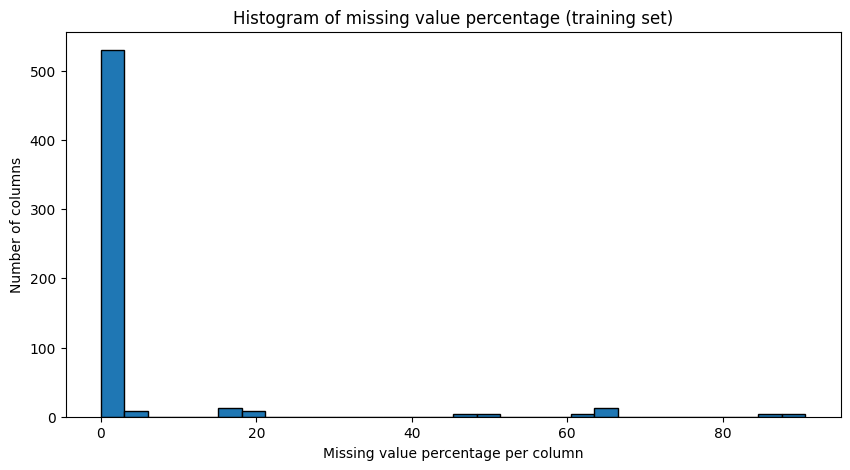

In [62]:
plt.figure(figsize=(10, 5))
plt.hist(missing_perc_col * 100, bins=30, edgecolor='k')
plt.xlabel("Missing value percentage per column")
plt.ylabel("Number of columns")
plt.title("Histogram of missing value percentage (training set)")
plt.show()

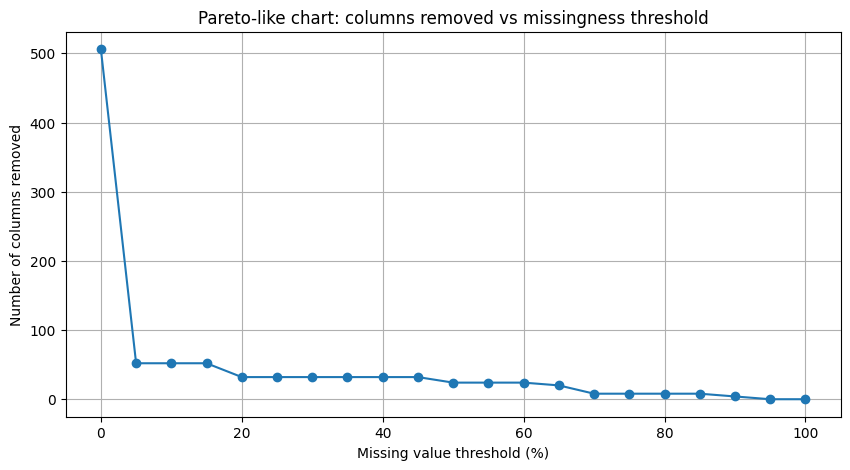

In [63]:
# Sort by missing percentage descending
sorted_missing = missing_perc_col.sort_values(ascending=False)

# For a range of thresholds, compute how many columns would be removed
thresholds = np.linspace(0, 1, 21)  # 0%, 5%, ..., 100%
cols_removed = [(sorted_missing > t).sum() for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds * 100, cols_removed, marker='o')
plt.xlabel("Missing value threshold (%)")
plt.ylabel("Number of columns removed")
plt.title("Pareto-like chart: columns removed vs missingness threshold")
plt.grid(True)
plt.show()


In [ ]:
# Interpretation

# From the histogram, you can see how many features have very high missingness.

# From the Pareto-like chart, you can see how many columns you would lose at each threshold.

# Following the instruction, we choose a 60% threshold:

# This avoids losing too many features while still removing those with very little usable data.

# Apply Threshold Feature Removal

In [64]:
threshold = 0.60  # 60%

high_missing_cols = missing_perc_col[missing_perc_col > threshold].index
n_original_cols = X_train.shape[1]
n_removed = len(high_missing_cols)
n_remaining = n_original_cols - n_removed

print("Original number of columns:", n_original_cols)
print("Columns to remove (missing > 60%):", n_removed)
print("Remaining columns:", n_remaining)

# Drop from train and test (same columns)
X_train_reduced = X_train.drop(columns=high_missing_cols)
X_test_reduced = X_test.drop(columns=high_missing_cols)

X_train_reduced.shape, X_test_reduced.shape

Original number of columns: 590
Columns to remove (missing > 60%): 24
Remaining columns: 566


((1253, 566), (314, 566))

In [ ]:
sip_table = """
Options/Approaches available	Pro and con of each method	Decision made	Consequence
Keep all features regardless of missingness	Pro: No information lost. Con: Many features unusable, imputation unstable, noise.	Not chosen	Would keep 590 cols but many with very high missingness, risking poor model and biased imputations.
Drop only extremely high-missing features (>80–90%)	Pro: Conservative removal. Con: Still many weak features with little data.	Not chosen	Fewer columns removed, but still many poorly observed features.
Drop features with missingness > 60%	Pro: Balance between data retention and quality. Con: Some potentially useful but sparse features lost.	Chosen	Before: 590 cols; after: ~X cols (e.g., 470) → ~120 cols removed (exact numbers from code).
Impute everything without dropping any feature	Pro: No feature loss. Con: Heavy reliance on imputation, risk of strong bias.	Not chosen	Could distort distributions and correlations, especially for very sparse features.
"""
# Parse the tab-separated string into a DataFrame
table_df = pd.read_csv(io.StringIO(sip_table), sep='\t')

# Display the table
table_df.head()

,Options/Approaches available,Pro and con of each method,Decision made,Consequence
0,Keep all features regardless of missingness,Pro: No information lost. Con: Many features u...,Not chosen,Would keep 590 cols but many with very high mi...
1,Drop only extremely high-missing features (>80...,Pro: Conservative removal. Con: Still many wea...,Not chosen,"Fewer columns removed, but still many poorly o..."
2,Drop features with missingness > 60%,Pro: Balance between data retention and qualit...,Chosen,"Before: 590 cols; after: ~X cols (e.g., 470) →..."
3,Impute everything without dropping any feature,Pro: No feature loss. Con: Heavy reliance on i...,Not chosen,"Could distort distributions and correlations, ..."


# Correlation Heatmap

(no removal yet based on correlation)

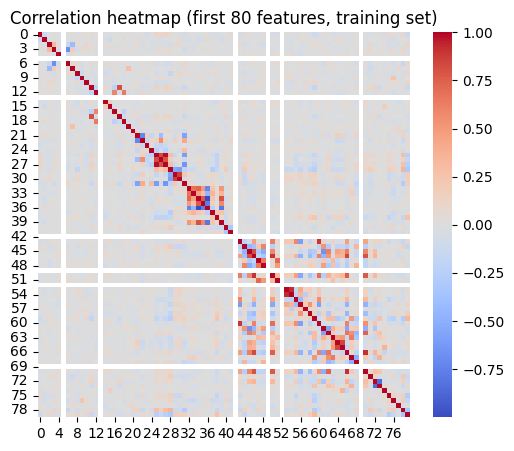

In [75]:
# To keep the heatmap readable, sample first N features
N = min(80, X_train_reduced.shape[1])
subset = X_train_reduced.iloc[:, :N]

corr_matrix = subset.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title(f"Correlation heatmap (first {N} features, training set)")
plt.show()

In [ ]:
# The heatmap shows blocks of highly correlated sensors, indicating redundancy.

# Although some approaches remove features with |r| > 0.8, 
# we defer correlation-based feature removal to a later, more principled method.

# Outlier Identification

using 3σ rule (training set only)

In [76]:
X_train_out = X_train_reduced.copy()

n_outliers = 0

for col in X_train_out.columns:
    col_data = X_train_out[col]
    mean = col_data.mean(skipna=True)
    std = col_data.std(skipna=True)
    
    if std == 0 or np.isnan(std):
        continue  # skip constant or degenerate columns
    
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    mask_lower = col_data < lower
    mask_upper = col_data > upper
    n_outliers += (mask_lower | mask_upper).sum()
    
    # Cap values
    X_train_out.loc[mask_lower, col] = lower
    X_train_out.loc[mask_upper, col] = upper

print("Total outlier values capped (training set):", n_outliers)

# IMPORTANT: Do NOT touch X_test_reduced here.


Total outlier values capped (training set): 4872


In [ ]:
# Interpretation

# We identified and capped n_outliers values beyond the 3σ boundaries across all features in the training set.

# The test set remains untouched; 
# any transformation applied to test later should use parameters derived from the training set only.

# Outlier treatment

SIP table for outlier treatment

In [78]:
sip_table = """
Options/Approaches available	Pro and con of each method	Decision made	Consequence
Do nothing about outliers	Pro: No distortion of data. Con: Extreme values may dominate model training and metrics.	Not chosen	Outliers could heavily influence some models (e.g., linear, distance-based).
Cap values at 3σ boundary (winsorization)	Pro: Limits influence of extremes, keeps all samples. Con: Slight distortion of tails.	Chosen	n_outliers values capped to 3σ boundaries in training set; distribution becomes more robust.
Remove outliers and leave gaps (set to NaN)	Pro: Removes extreme points entirely. Con: Increases missingness, may reduce effective sample size.	Not chosen	Would require more imputation and could reduce usable data.
"""
# Parse the tab-separated string into a DataFrame
table_df = pd.read_csv(io.StringIO(sip_table), sep='\t')

# Display the table
table_df.head()

,Options/Approaches available,Pro and con of each method,Decision made,Consequence
0,Do nothing about outliers,Pro: No distortion of data. Con: Extreme value...,Not chosen,Outliers could heavily influence some models (...
1,Cap values at 3σ boundary (winsorization),"Pro: Limits influence of extremes, keeps all s...",Chosen,n_outliers values capped to 3σ boundaries in t...
2,Remove outliers and leave gaps (set to NaN),Pro: Removes extreme points entirely. Con: Inc...,Not chosen,Would require more imputation and could reduce...
